In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (replace with your actual file names)
# File 1 contains Raw observations and Final results
df_a = pd.read_csv('results/master_denominator_report.csv', usecols=['sample', 'total_raw_observations', 'final_callable_bases'])

# File 2 contains WES and WES-Blacklist stats
df_b = pd.read_csv('../denominator_calculations_v2/complete_processed_padding_metadata.csv', usecols=['sample_id', 'total_bases_in_padded_wes', 'total_bases_in_wes'])

# 2. Define the manual mapping for outliers
# We will rename the IDs in df_b to match the IDs in df_a
id_map = {
    '27YO_UDI5': '27YO_PBMC_CD4',
    '27YO_UDI6': '27YO_PBMC_CD8',
    'UD21_3x': 'LEG_002_PBMC_CD4',
    'UD22_3x': 'LEG_002_PBMC_CD8',
    'UDI23_3x': 'LEG_004_PBMC_CD4',
    'UDI24_3x': 'LEG_004_PBMC_CD8'
}

# Apply the mapping: if sample_id is in the map, rename it; otherwise keep original
df_b['mapped_id'] = df_b['sample_id'].replace(id_map)

# 3. Merge on the corrected IDs
# Using an 'inner' join ensures we only keep samples present in both files
df = pd.merge(
    df_a, 
    df_b, 
    left_on='sample', 
    right_on='mapped_id'
)

# Define the stages in order
stages = {
    'Raw': 'total_bases_in_padded_wes',
    'WES': 'total_bases_in_wes',
    'WES - Blacklist': 'total_raw_observations',
    'Final': 'final_callable_bases'
}

# Melt the dataframe for plotting (Long Format)
plot_df = df.melt(id_vars=['sample'], 
                  value_vars=list(stages.values()),
                  var_name='Stage', 
                  value_name='Depth')

# Map the column names back to pretty stage names
inv_stages = {v: k for k, v in stages.items()}
plot_df['Stage'] = plot_df['Stage'].map(inv_stages)
plot_df['Stage'] = pd.Categorical(plot_df['Stage'], categories=list(stages.keys()), ordered=True)

print(f"Successfully loaded {len(df)} matching samples.")
df.head()

Successfully loaded 36 matching samples.


,sample,total_raw_observations,final_callable_bases,sample_id,total_bases_in_wes,total_bases_in_padded_wes,mapped_id
0,27YO_PBMC_CD4,1614043080,1368661165,27YO_UDI5,2484451933,4044481231,27YO_PBMC_CD4
1,27YO_PBMC_CD8,2096031641,1765503786,27YO_UDI6,3175577685,5112971137,27YO_PBMC_CD8
2,LEG_002_PBMC_CD4,10788190554,9132618912,UD21_3x,17849564526,26619332800,LEG_002_PBMC_CD4
3,LEG_002_PBMC_CD8,13479708200,11512802602,UD22_3x,21872769498,33230868917,LEG_002_PBMC_CD8
4,LEG_004_PBMC_CD4,10526447001,9004558796,UDI23_3x,18629658702,27790348725,LEG_004_PBMC_CD4


/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_20827/1308221315.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x='Stage', y='Depth',


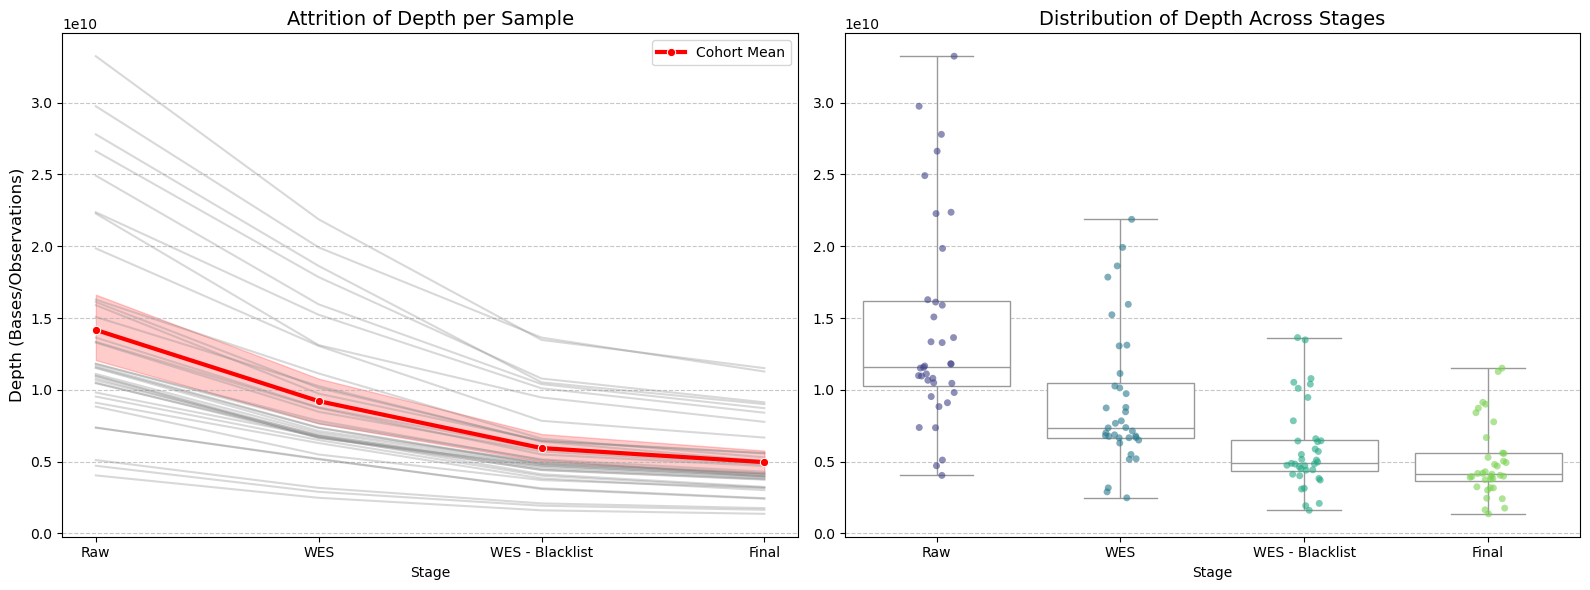

In [3]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Parallel Coordinates (Spaghetti Plot) ---
# We use lineplot with 'units' and 'estimator=None' to draw individual lines
sns.lineplot(data=plot_df, x='Stage', y='Depth', units='sample', 
             estimator=None, color='gray', alpha=0.3, ax=ax1)

# Add a mean line to show the average trend
sns.lineplot(data=plot_df, x='Stage', y='Depth', 
             color='red', linewidth=3, marker='o', ax=ax1, label='Cohort Mean')

ax1.set_title('Attrition of Depth per Sample', fontsize=14)
ax1.set_ylabel('Depth (Bases/Observations)', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Boxplot with Jittered Points ---
sns.boxplot(data=plot_df, x='Stage', y='Depth', whis=np.inf, 
            color='white', ax=ax2, showfliers=False)
sns.stripplot(data=plot_df, x='Stage', y='Depth', 
              jitter=True, alpha=0.6, palette='viridis', ax=ax2)

ax2.set_title('Distribution of Depth Across Stages', fontsize=14)
ax2.set_ylabel('') # Y-axis shared with Plot 1
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Handle Log Scale if depth drops are massive (e.g., millions to thousands)
# ax1.set_yscale('log')
# ax2.set_yscale('log')

plt.tight_layout()
plt.show()

Normalized data for 36 samples.


/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_20827/2161030809.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Stage', y='Percentage', ax=ax2,
/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_20827/2161030809.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = plot_df.groupby('Stage')['Percentage'].mean()


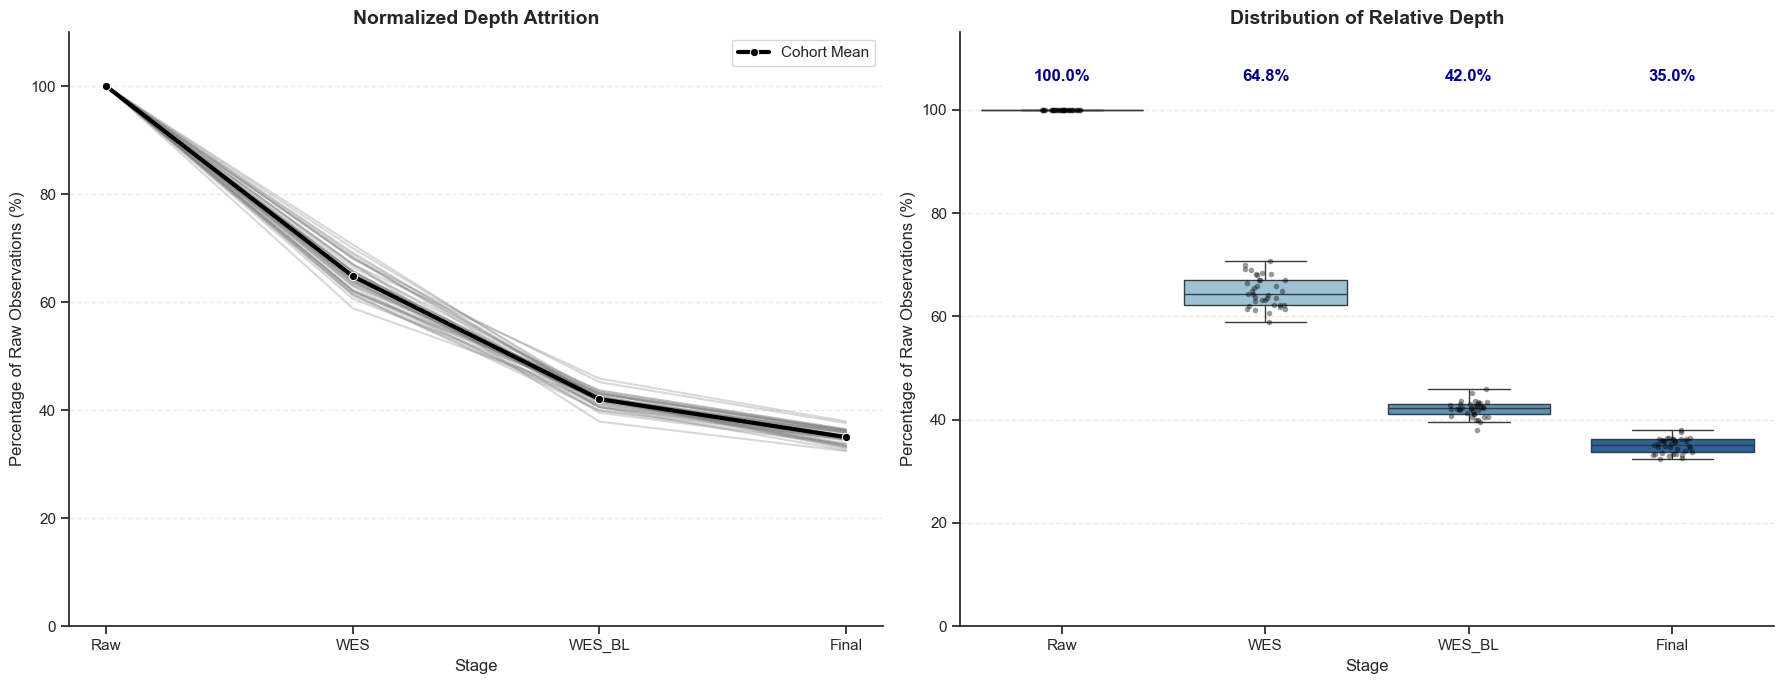

In [7]:
# 4. Normalize: (Stage / Raw) * 100
# We create a new dataframe with percentage values
norm_df = pd.DataFrame()
norm_df['sample'] = df['sample']
norm_df['Raw'] = 100.0  # Starting point is always 100%
norm_df['WES'] = (df['total_bases_in_wes'] / df['total_bases_in_padded_wes']) * 100
norm_df['WES_BL'] = (df['total_raw_observations'] / df['total_bases_in_padded_wes']) * 100
norm_df['Final'] = (df['final_callable_bases'] / df['total_bases_in_padded_wes']) * 100

# Melt for Seaborn plotting
plot_df = norm_df.melt(id_vars='sample', var_name='Stage', value_name='Percentage')
order = ['Raw', 'WES', 'WES_BL', 'Final']
plot_df['Stage'] = pd.Categorical(plot_df['Stage'], categories=order, ordered=True)

print(f"Normalized data for {len(norm_df)} samples.")
norm_df.head()

sns.set_theme(style="ticks")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Normalized Spaghetti Plot ---
sns.lineplot(data=plot_df, x='Stage', y='Percentage', units='sample', 
             estimator=None, color='gray', alpha=0.3, ax=ax1)

# Highlight the mean trend line
sns.lineplot(data=plot_df, x='Stage', y='Percentage', 
             color='black', linewidth=3, marker='o', ax=ax1, label='Cohort Mean')

ax1.set_title('Normalized Depth Attrition', fontsize=14, fontweight='bold')
ax1.set_ylabel('Percentage of Raw Observations (%)')
ax1.set_ylim(0, 110)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- Plot 2: Boxplot with Mean Annotations ---
sns.boxplot(data=plot_df, x='Stage', y='Percentage', ax=ax2, 
            showfliers=False, palette='Blues')
sns.stripplot(data=plot_df, x='Stage', y='Percentage', ax=ax2, 
              jitter=True, alpha=0.4, color='black', size=4)

# Calculate means for the annotations
means = plot_df.groupby('Stage')['Percentage'].mean()

# Add the "% Kept" labels above the boxes
for i, stage in enumerate(order):
    mean_val = means[stage]
    ax2.text(i, 105, f'{mean_val:.1f}%', 
             ha='center', va='bottom', fontweight='bold', color='darkblue')

ax2.set_title('Distribution of Relative Depth', fontsize=14, fontweight='bold')
ax2.set_ylabel('Percentage of Raw Observations (%)')
ax2.set_ylim(0, 115) # Leave room for labels
ax2.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_20827/2451460845.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted_filters, x='Filter', y='Count', ax=ax1, palette='magma')
/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_20827/2451460845.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=melted_filters, x='Filter', y='Percentage_Loss', ax=ax2, palette='magma', errorbar='sd')


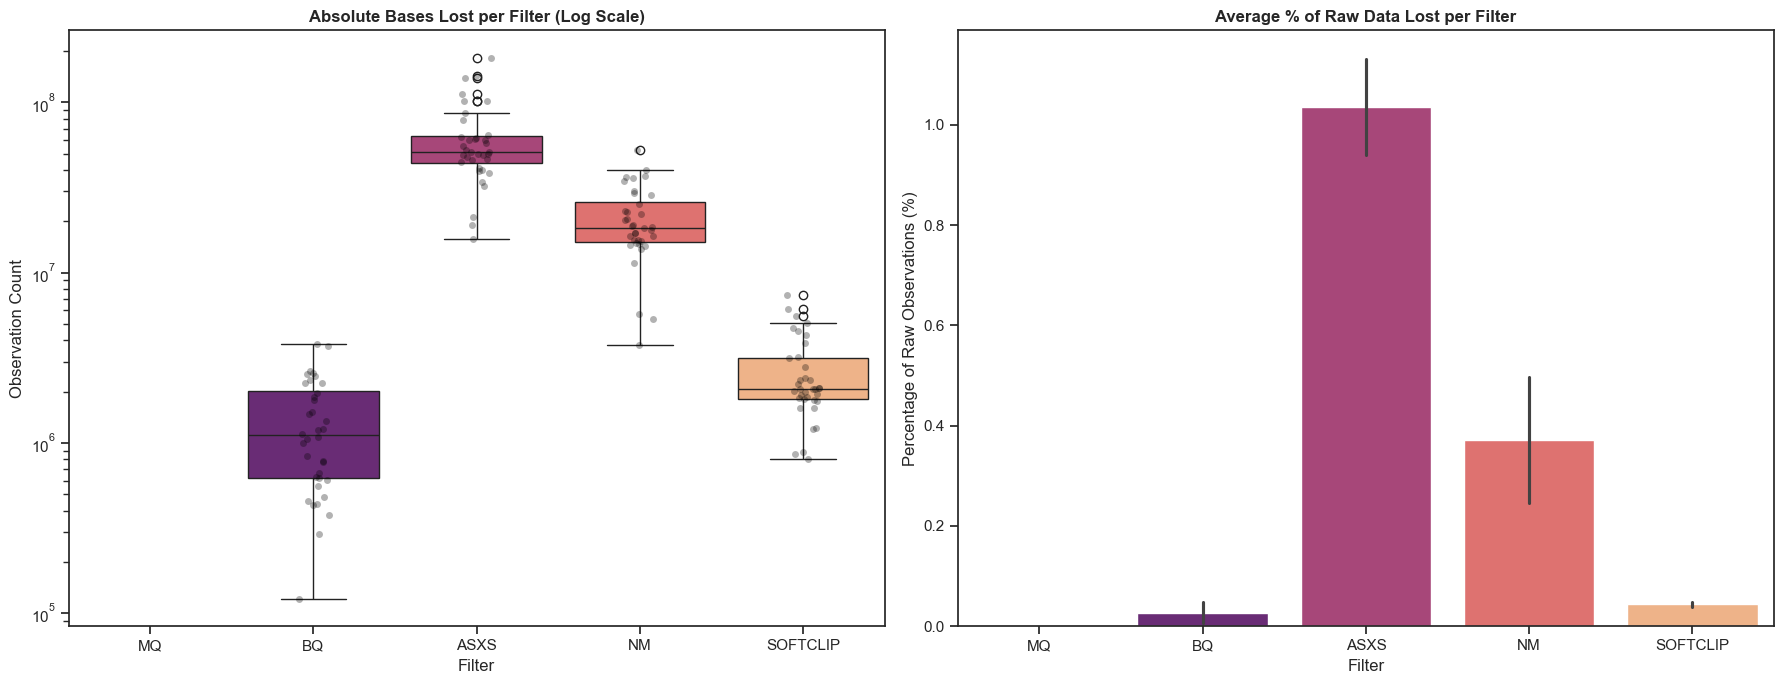

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the specific filter columns
filter_cols = [
    'marginal_gain_MQ', 
    'marginal_gain_BQ', 
    'marginal_gain_ASXS', 
    'marginal_gain_NM', 
    'marginal_gain_SOFTCLIP'
]

df_filters = pd.read_csv('results/master_denominator_report.csv', 
                         usecols=['sample', 'total_raw_observations'] + filter_cols)

# 2. Melt data for plotting
melted_filters = df_filters.melt(
    id_vars=['sample', 'total_raw_observations'], 
    value_vars=filter_cols, 
    var_name='Filter', 
    value_name='Count'
)

# Clean up filter names (remove 'marginal_gain_')
melted_filters['Filter'] = melted_filters['Filter'].str.replace('marginal_gain_', '')

# 3. Calculate Percentage Loss (Optional but recommended for comparison)
# This shows: "What % of my total raw data was lost to this specific filter?"
melted_filters['Percentage_Loss'] = (melted_filters['Count'] / melted_filters['total_raw_observations']) * 100

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot A: Absolute Counts (Log Scale)
sns.boxplot(data=melted_filters, x='Filter', y='Count', ax=ax1, palette='magma')
sns.stripplot(data=melted_filters, x='Filter', y='Count', ax=ax1, color='black', alpha=0.3)
ax1.set_yscale('log')
ax1.set_title('Absolute Bases Lost per Filter (Log Scale)', fontweight='bold')
ax1.set_ylabel('Observation Count')

# Plot B: Percentage Impact (Linear Scale)
sns.barplot(data=melted_filters, x='Filter', y='Percentage_Loss', ax=ax2, palette='magma', errorbar='sd')
ax2.set_title('Average % of Raw Data Lost per Filter', fontweight='bold')
ax2.set_ylabel('Percentage of Raw Observations (%)')

plt.tight_layout()
plt.show()